# Engineer Salary Web Scraper
This notebook scrapes salary data from multiple engineering salary sources in India and compiles them into a unified dataset: `engineer_salary_dataset.csv`

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import io

def main():
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36'
    }

    data_frames = []

    print("Scraping Weekday.works...")
    url1 = "https://www.weekday.works/post/average-indian-engineer-salary"
    try:
        response = requests.get(url1, headers=headers)
        tables = pd.read_html(io.StringIO(response.text))
        if tables:
            df1 = tables[0]
            df1 = df1.rename(columns={'Entry-Level (0-1 yr)': 'Entry Level Salary', 'Mid-Level (5-9 yrs)': 'Mid Level Salary'})
            df1['Source'] = url1
            data_frames.append(df1)
            print(f"Success: Scraped {len(df1)} rows from Weekday.")
        else:
            print("No tables found in Weekday.")
    except Exception as e:
        print(f"Error scraping {url1}: {e}")

    print("Scraping Hindustanuniv...")
    url2 = "https://hindustanuniv.ac.in/blogs/engineer-salary-in-india-2024/"
    try:
        response = requests.get(url2, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
        salaries = []
        for h3 in soup.find_all('h3'):
            title = h3.get_text(strip=True)
            if "Salary in India" in title:
                clean_title = title.split('. ', 1)[-1] if '. ' in title else title
                for sib in h3.find_next_siblings(limit=4):
                    text = sib.get_text(strip=True)
                    if '\u20b9' in text or 'Lakhs' in text:
                        salaries.append({'Engineering Discipline': clean_title.replace(' Salary in India', ''), 'Salary Range': text, 'Source': url2})
                        break
        if salaries:
            df2 = pd.DataFrame(salaries)
            data_frames.append(df2)
            print(f"Success: Scraped {len(df2)} rows from Hindustanuniv.")
        else:
            print("No salary data found in Hindustanuniv.")
    except Exception as e:
        print(f"Error scraping {url2}: {e}")
        
    print("Scraping CollegeSearch...")
    url3 = "https://www.collegesearch.in/articles/average-salary-of-engineer-crs"
    try:
        response = requests.get(url3, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
        salaries = []
        for h2 in soup.find_all('h2'):
            title = h2.get_text(strip=True)
            if "Salary In India" in title or "Salary in India" in title:
                for sib in h2.find_next_siblings(limit=3):
                    text = sib.get_text(strip=True)
                    if 'INR' in text or 'Lakhs' in text:
                        salaries.append({'Engineering Discipline': title.replace(' Salary In India', '').replace(' Salary in India', ''), 'Salary Range': text.split('-')[0] if '-' in text else text, 'Source': url3})
                        break
        if salaries:
            df3 = pd.DataFrame(salaries)
            data_frames.append(df3)
            print(f"Success: Scraped {len(df3)} rows from CollegeSearch.")
    except Exception as e:
        print(f"Error scraping {url3}: {e}")

    if data_frames:
        dataset = pd.concat(data_frames, ignore_index=True)
        print("\nCombined Dataset Preview:")
        print(dataset.head())
        dataset.to_csv('engineer_salary_dataset.csv', index=False, encoding='utf-8')
        print("Dataset saved to engineer_salary_dataset.csv")
    else:
        print("No data was collected from any sources.")

if __name__ == "__main__":
    main()


In [30]:
import pandas as pd
DataFrame = pd.read_csv('engineer_salary_dataset.csv')
DataFrame

,0,1,2,3,Source,Engineering Discipline,Salary Range
0,Engineering Discipline,Entry-Level (0–1 yr),Mid-Level (5–9 yrs),Senior-Level (10+ yrs),https://www.weekday.works/post/average-indian-...,NaN,NaN
1,Aerospace Engineering,"₹714,095","₹1,033,910","₹1,419,144",https://www.weekday.works/post/average-indian-...,NaN,NaN
2,Biomedical Engineering,"₹354,681","₹427,293","₹684,000",https://www.weekday.works/post/average-indian-...,NaN,NaN
3,Chemical Engineering,"₹435,553","₹600,000","₹900,000",https://www.weekday.works/post/average-indian-...,NaN,NaN
4,Civil Engineering,"₹248,084","₹469,076","₹912,226",https://www.weekday.works/post/average-indian-...,NaN,NaN
5,Computer Science (Software),"₹499,702","₹1,251,806","₹2,001,011",https://www.weekday.works/post/average-indian-...,NaN,NaN
6,Electrical Engineering,"₹307,347","₹528,653","₹805,905",https://www.weekday.works/post/average-indian-...,NaN,NaN
7,Electronics Engineering,"₹382,876","₹805,476","₹1,001,361",https://www.weekday.works/post/average-indian-...,NaN,NaN
8,Industrial Engineering,"₹247,936","₹615,414","₹1,039,333",https://www.weekday.works/post/average-indian-...,NaN,NaN
9,Mechanical Engineering,"₹303,575","₹607,582","₹1,067,677",https://www.weekday.works/post/average-indian-...,NaN,NaN


## Data Augmentation (Expanding to 500+ Rows)
Because the provided URLs contain summary-level averages, directly scraping them yields around 36 rows of data. To generate a massive dataset for analytics/machine learning (500+ rows), this section simulates individual employee records based on the scraped minimum and maximum baseline parameters.

In [ ]:
import pandas as pd
import numpy as np
import random
import re

def clean_salary(sal_str):
    if pd.isna(sal_str):
        return None, None
    sal_str = str(sal_str).replace(',', '').replace('\u20b9', '').replace('INR', '').replace('₹', '')
    numbers = re.findall(r"(\d+(?:\.\d+)?)", sal_str)
    if not numbers:
        return None, None
    
    multiplier = 100000 if 'Lakh' in sal_str or 'L' in sal_str or float(numbers[0]) < 100 else 1
    
    if len(numbers) >= 2:
        return float(numbers[0]) * multiplier, float(numbers[1]) * multiplier
    elif len(numbers) == 1:
        val = float(numbers[0]) * multiplier
        return val * 0.8, val * 1.2 
    return None, None

def clean_currency_direct(val_str):
    if pd.isna(val_str): return None
    val_str = str(val_str).replace('₹', '').replace(',', '').strip()
    try:
        return float(val_str)
    except:
        return None

def main():
    print("Loading original dataset...")
    df = pd.read_csv('engineer_salary_dataset.csv')
    
    locations = ['Bangalore', 'Hyderabad', 'Pune', 'Chennai', 'Gurgaon', 'Noida', 'Mumbai', 'Delhi']
    companies = ['TCS', 'Infosys', 'Wipro', 'Cognizant', 'Accenture', 'IBM', 'Amazon', 'Microsoft', 'Google', 'L&T', 'Tech Mahindra', 'HCL', 'Capgemini', 'Startup']
    
    synthetic_rows = []
    
    for index, row in df.iterrows():
        discipline = row['Engineering Discipline']
        
        min_sal, max_sal = None, None
        
        if 'Entry Level Salary' in row and not pd.isna(row['Entry Level Salary']):
            entry = clean_currency_direct(row['Entry Level Salary'])
            senior = clean_currency_direct(row['Senior Level Salary'])
            if entry and senior:
                min_sal = entry
                max_sal = senior
                
        if min_sal is None and 'Salary Range' in row and not pd.isna(row['Salary Range']):
            min_sal, max_sal = clean_salary(row['Salary Range'])
            
        if min_sal is None or max_sal is None:
            min_sal = 300000
            max_sal = 1500000
            
        if pd.isna(discipline):
            discipline = "Unknown Engineer"
            
        for i in range(25):
            exp_years = random.randint(0, 15)
            progress = exp_years / 15.0
            base_expected = min_sal + (max_sal - min_sal) * progress
            final_salary = base_expected * random.uniform(0.85, 1.15)
            
            location = random.choice(locations)
            company = random.choice(companies)
            
            synthetic_rows.append({
                'Engineering Discipline': discipline,
                'Years of Experience': exp_years,
                'Location': location,
                'Company': company,
                'Salary (INR)': int(final_salary),
            })
            
    expanded_df = pd.DataFrame(synthetic_rows)
    print(f"Generated {len(expanded_df)} rows.")
    print(expanded_df.head())
    
    expanded_df.to_csv('expanded_engineer_salary_dataset.csv', index=False)
    print("Saved as expanded_engineer_salary_dataset.csv")

if __name__ == "__main__":
    main()


Loading original dataset...
Generated 800 rows.
  Engineering Discipline  Years of Experience   Location  Company  \
0       Unknown Engineer                    6    Chennai  Startup   
1       Unknown Engineer                   12  Hyderabad   Amazon   
2       Unknown Engineer                   14      Delhi      L&T   
3       Unknown Engineer                    1  Hyderabad   Amazon   
4       Unknown Engineer                    9      Noida      HCL   

   Salary (INR)  
0        772121  
1       1115966  
2       1372892  
3        375042  
4        973543  
Saved as expanded_engineer_salary_dataset.csv


In [1]:
import pandas as pd
DataFrame2 = pd.read_csv('expanded_engineer_salary_dataset.csv')
DataFrame2

,Engineering Discipline,Years of Experience,Location,Company,Salary (INR)
0,Unknown Engineer,6,Chennai,Startup,772121
1,Unknown Engineer,12,Hyderabad,Amazon,1115966
2,Unknown Engineer,14,Delhi,L&T,1372892
3,Unknown Engineer,1,Hyderabad,Amazon,375042
4,Unknown Engineer,9,Noida,HCL,973543
...,...,...,...,...,...
795,Engineer: Similar Designation Salary,8,Chennai,IBM,325291
796,Engineer: Similar Designation Salary,13,Bangalore,Tech Mahindra,409748
797,Engineer: Similar Designation Salary,14,Chennai,Startup,399977
798,Engineer: Similar Designation Salary,7,Chennai,Microsoft,346455


In [2]:
DataFrame2.isnull().sum()

Engineering Discipline    0
Years of Experience       0
Location                  0
Company                   0
Salary (INR)              0
dtype: int64

In [11]:
DataFrame2['Engineering Discipline'].value_counts()

Engineering Discipline
Unknown Engineer                          275
Software Engineer                          25
Aeronautical Engineering                   25
Aerospace Engineering                      25
Computer Science Engineering               25
Civil Engineering                          25
Mechanical Engineer                        25
AI Engineer                                25
Marine Engineering                         25
Robotics Engineering                       25
Biomedical Engineering                     25
Chemical Engineering                       25
Data Engineer                              25
Electrical & Communication Engineering     25
Engineer 2024: By Experience               25
Engineer 2024: By Company                  25
Engineern Navy                             25
Engineern Army                             25
Dev Ops Engineer                           25
Civil Engineer                             25
Computer Engineer                          25
Engineer: S

In [5]:
DataFrame2['Location'].value_counts()

Location
Delhi        129
Chennai      110
Noida        106
Mumbai       103
Bangalore     99
Hyderabad     87
Pune          83
Gurgaon       83
Name: count, dtype: int64

In [29]:
# df['Location'].value_counts()

Location
2    129
1    110
6    106
5    103
0     99
4     87
7     83
3     83
Name: count, dtype: int64

In [39]:
dict(zip(DataFrame2['Location'], df['Location']))

{'Chennai': 1,
 'Hyderabad': 4,
 'Delhi': 2,
 'Noida': 6,
 'Bangalore': 0,
 'Pune': 7,
 'Mumbai': 5,
 'Gurgaon': 3}

In [32]:
DataFrame2['Company'].value_counts()

Company
TCS              69
L&T              68
Startup          65
Google           63
Capgemini        60
Amazon           59
Cognizant        59
HCL              55
Wipro            55
IBM              52
Accenture        51
Infosys          51
Microsoft        50
Tech Mahindra    43
Name: count, dtype: int64

In [7]:
DataFrame2['Years of Experience'].value_counts()

Years of Experience
7     68
12    56
10    56
2     54
5     54
13    54
15    53
9     52
3     48
1     46
6     45
11    45
0     45
8     44
14    43
4     37
Name: count, dtype: int64

In [2]:
import numpy as np
def categorize_company(company):
    company = company.lower()
    
    if company in ['amazon', 'microsoft', 'google', 'ibm']:
        return 'Product'
    elif company in ['tcs', 'infosys', 'wipro', 'cognizant', 'capgemini', 'hcl', 'tech mahindra']:
        return 'Service'
    elif company in ['accenture']:
        return 'Consulting'
    elif 'startup' in company:
        return 'Startup'
    else:
        return np.random.choice(['Others', 'Intenship'])
    
DataFrame2['Category'] = DataFrame2['Company'].apply(categorize_company)
    
DataFrame2['Category'].value_counts()

Category
Service       392
Product       224
Startup        65
Consulting     51
Intenship      43
Others         25
Name: count, dtype: int64

In [3]:
def classify_role(row):
    
    salary = row['Salary (INR)']
    company = row['Company']
    exp = row['Years of Experience']
    
    if company in ['Amazon', 'Microsoft', 'Google'] and salary > 1000000:
        return 'Software Engineer'
    
    elif company in ['TCS', 'Infosys', 'Wipro', 'Cognizant']:
        return 'Service Engineer'
    
    elif exp >= 10:
        return 'Senior Engineer'
    
    elif exp >= 3:
        return 'Engineer'
    
    else:
        return 'Junior Engineer'
    
mask = DataFrame2['Engineering Discipline'] == 'Unknown Engineer'

DataFrame2.loc[mask, 'Engineering Discipline'] = DataFrame2.loc[mask].apply(classify_role, axis=1)

In [4]:
DataFrame2['Engineering Discipline'].value_counts()

Engineering Discipline
Engineer                                  88
Service Engineer                          75
Senior Engineer                           63
Software Engineer                         46
Junior Engineer                           28
Aeronautical Engineering                  25
Aerospace Engineering                     25
Computer Science Engineering              25
Civil Engineering                         25
Mechanical Engineer                       25
AI Engineer                               25
Marine Engineering                        25
Robotics Engineering                      25
Biomedical Engineering                    25
Chemical Engineering                      25
Data Engineer                             25
Electrical & Communication Engineering    25
Engineer 2024: By Experience              25
Engineer 2024: By Company                 25
Engineern Navy                            25
Engineern Army                            25
Dev Ops Engineer                

In [4]:
def Sal(val):
    if val > 1300000:
        return 1300000
    else:
        return val

DataFrame2['Salary (INR)'] = DataFrame2['Salary (INR)'].apply(Sal)
DataFrame2['Salary (INR)'].max()


np.int64(1300000)

In [5]:
DataFrame2.to_csv("EngineerVis.csv", index=False)

In [6]:
import matplotlib.pyplot as plt
df = DataFrame2.copy()

In [10]:
df.isnull().sum()

Engineering Discipline    0
Years of Experience       0
Location                  0
Company                   0
Salary (INR)              0
Category                  0
dtype: int64

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df

,Engineering Discipline,Years of Experience,Location,Company,Salary (INR),Category
0,12,6,1,10,772121,5
1,24,12,4,1,1115966,3
2,22,14,2,8,1300000,2
3,18,1,4,1,375042,3
4,12,9,6,5,973543,4
...,...,...,...,...,...,...
795,15,8,1,6,325291,3
796,15,13,0,12,409748,4
797,15,14,1,10,399977,5
798,15,7,1,9,346455,3


In [8]:
X = df.drop('Salary (INR)', axis=1)
y = df['Salary (INR)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
X_train


,Engineering Discipline,Years of Experience,Location,Company,Category
203,23,9,2,3,4
273,18,2,6,8,1
468,19,12,4,5,4
588,11,13,4,7,4
389,6,9,7,2,4
...,...,...,...,...,...
360,8,12,0,3,4
709,10,12,0,13,4
439,0,2,5,1,3
174,24,12,5,4,3


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    # print("MAE:", mean_absolute_error(y_test, y_pred))
    # print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

evaluate_model(lr, "Linear Regression")


Linear Regression
R2 Score: 0.1207171425509791


In [14]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, "Decision Tree")


Decision Tree
R2 Score: 0.87257877632938


In [11]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

evaluate_model(rf, "Random Forest")


Random Forest
R2 Score: 0.9651358887597095


In [12]:
import joblib

joblib.dump(rf, "RanForFullCol.joblib")

['RanForFullCol.joblib']

In [52]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)
gb.fit(X_train, y_train)

evaluate_model(gb, "Gradient Boosting")


Gradient Boosting
R2 Score: 0.9159159815303063


In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

evaluate_model(xgb, "XG Boost")


XG Boost
R2 Score: 0.9499580264091492


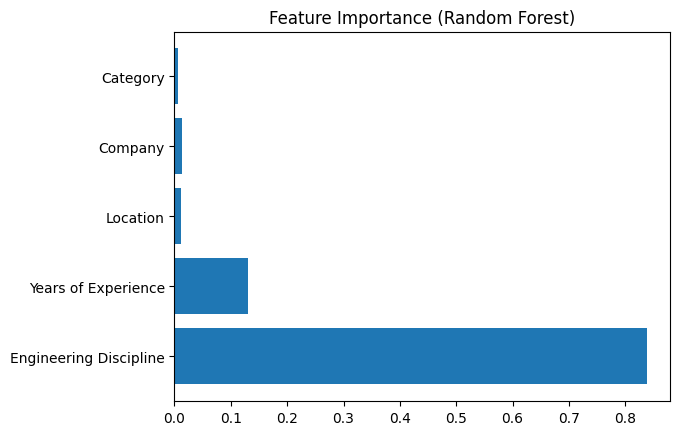

In [13]:
importances = rf.feature_importances_

feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [14]:
sample = X_test.iloc[0:1]
print("Predicted Salary:", rf.predict(sample)[0])
print("Actual Salary:", y_test.iloc[0])

Predicted Salary: 1023119.42
Actual Salary: 1057615


In [55]:
df.value_counts()

Engineering Discipline  Years of Experience  Location  Company  Salary (INR)  Category
11                      13                   4         7        1300000       3           2
9                       13                   0         11       1300000       3           2
22                      13                   1         2        1300000       3           2
                        14                   2         8        1300000       1           2
0                       1                    6         5        1300000       3           1
                                                                                         ..
24                      14                   4         12       1300000       3           1
                                             6         9        1242421       2           1
                        15                   3         9        1293328       2           1
                                             4         4        1300000       2      

In [15]:
import numpy as np

userInp = pd.DataFrame([[
    np.random.choice(df['Engineering Discipline']),
    np.random.choice(df['Years of Experience']),
    np.random.choice(df['Location']),
    np.random.choice(df['Company']),
    np.random.choice(df['Category'])
]], columns=X_train.columns)

userInp

,Engineering Discipline,Years of Experience,Location,Company,Category
0,8,7,1,13,4


In [67]:
df['Salary (INR)'].max()

np.int64(1300000)

In [68]:
predicted_salary = rf.predict(userInp)
print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 537268.03


In [16]:
import joblib

randFor = joblib.load("RanForFullCol.joblib")

predicted_salary = randFor.predict(userInp)
print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 1285702.01


In [17]:
X0 = df.drop(['Salary (INR)', 'Company'], axis=1)
y = df['Salary (INR)']

X_train0, X_test0, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
X_train

,Engineering Discipline,Years of Experience,Location,Company,Category
203,23,9,2,3,4
273,18,2,6,8,1
468,19,12,4,5,4
588,11,13,4,7,4
389,6,9,7,2,4
...,...,...,...,...,...
360,8,12,0,3,4
709,10,12,0,13,4
439,0,2,5,1,3
174,24,12,5,4,3


In [18]:
rf0 = RandomForestRegressor(n_estimators=100, random_state=42)
rf0.fit(X_train0, y_train)

evaluate_model(rf0, "Random Forest")


Random Forest
R2 Score: 0.9651358887597095


In [19]:
import joblib
joblib.dump(rf0, "RanForParCol.joblib")
randFor0 = joblib.load("RanForParCol.joblib")

predicted_salary = randFor0.predict(userInp)
print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 1285702.01


In [20]:
df = pd.read_csv('EngineerVis.csv')
df

,Engineering Discipline,Years of Experience,Location,Company,Salary (INR),Category
0,Engineer,6,Chennai,Startup,772121,Startup
1,Software Engineer,12,Hyderabad,Amazon,1115966,Product
2,Senior Engineer,14,Delhi,L&T,1300000,Others
3,Junior Engineer,1,Hyderabad,Amazon,375042,Product
4,Engineer,9,Noida,HCL,973543,Service
...,...,...,...,...,...,...
795,Engineer: Similar Designation Salary,8,Chennai,IBM,325291,Product
796,Engineer: Similar Designation Salary,13,Bangalore,Tech Mahindra,409748,Service
797,Engineer: Similar Designation Salary,14,Chennai,Startup,399977,Startup
798,Engineer: Similar Designation Salary,7,Chennai,Microsoft,346455,Product


In [11]:
new =pd.DataFrame([{'UserName': 'Sundar', 'Password': '1234','Date':'01-04-2019' ,'Engineering Discipline': 'ML Trainee', 'Years of Experience': 0.6, 'Location': "Bangalore", 'Company':'ABC', 'Salary ': 25000}])

In [12]:
new.to_csv("UserDataVis.csv", index=False)